In [31]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
df = pd.read_csv('Admission_Predict.csv')
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         400 non-null    int64  
 1   GRE Score          400 non-null    int64  
 2   TOEFL Score        400 non-null    int64  
 3   University Rating  400 non-null    int64  
 4   SOP                400 non-null    float64
 5   LOR                400 non-null    float64
 6   CGPA               400 non-null    float64
 7   Research           400 non-null    int64  
 8   Chance of Admit    400 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 28.3 KB


In [2]:
df.isnull().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

In [3]:
df.drop('Serial No.', axis=1, inplace=True)

In [5]:
corr_matrix = df.corr()
print(corr_matrix)

                   GRE Score  TOEFL Score  University Rating       SOP  \
GRE Score           1.000000     0.835977           0.668976  0.612831   
TOEFL Score         0.835977     1.000000           0.695590  0.657981   
University Rating   0.668976     0.695590           1.000000  0.734523   
SOP                 0.612831     0.657981           0.734523  1.000000   
LOR                 0.557555     0.567721           0.660123  0.729593   
CGPA                0.833060     0.828417           0.746479  0.718144   
Research            0.580391     0.489858           0.447783  0.444029   
Chance of Admit     0.802610     0.791594           0.711250  0.675732   

                       LOR       CGPA  Research  Chance of Admit   
GRE Score          0.557555  0.833060  0.580391          0.802610  
TOEFL Score        0.567721  0.828417  0.489858          0.791594  
University Rating  0.660123  0.746479  0.447783          0.711250  
SOP                0.729593  0.718144  0.444029          0.67

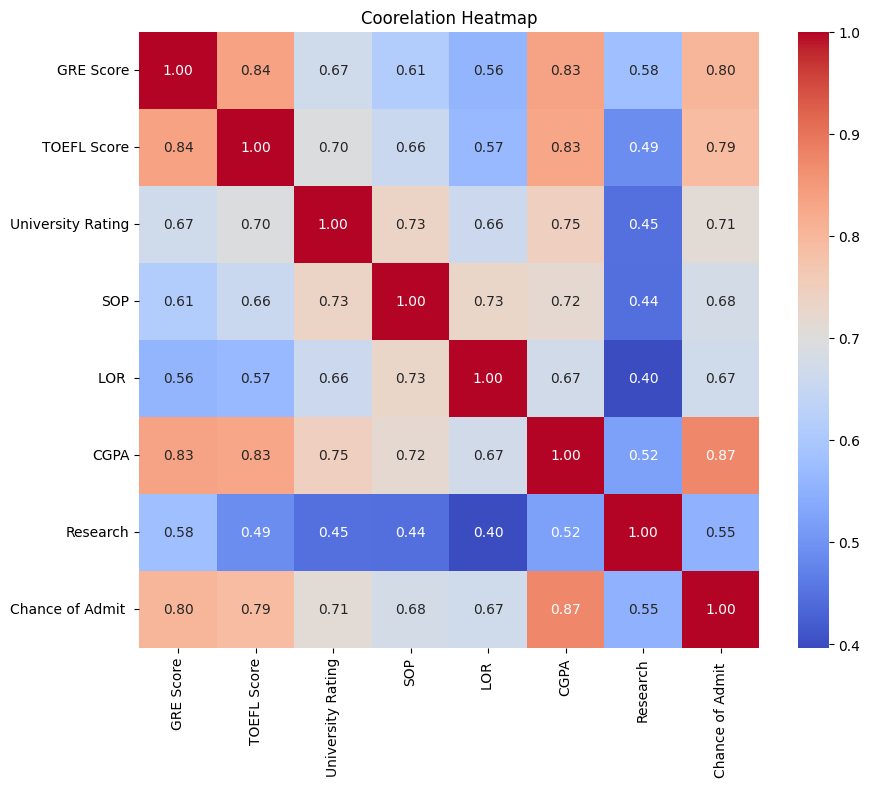

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Coorelation Heatmap')
plt.show()

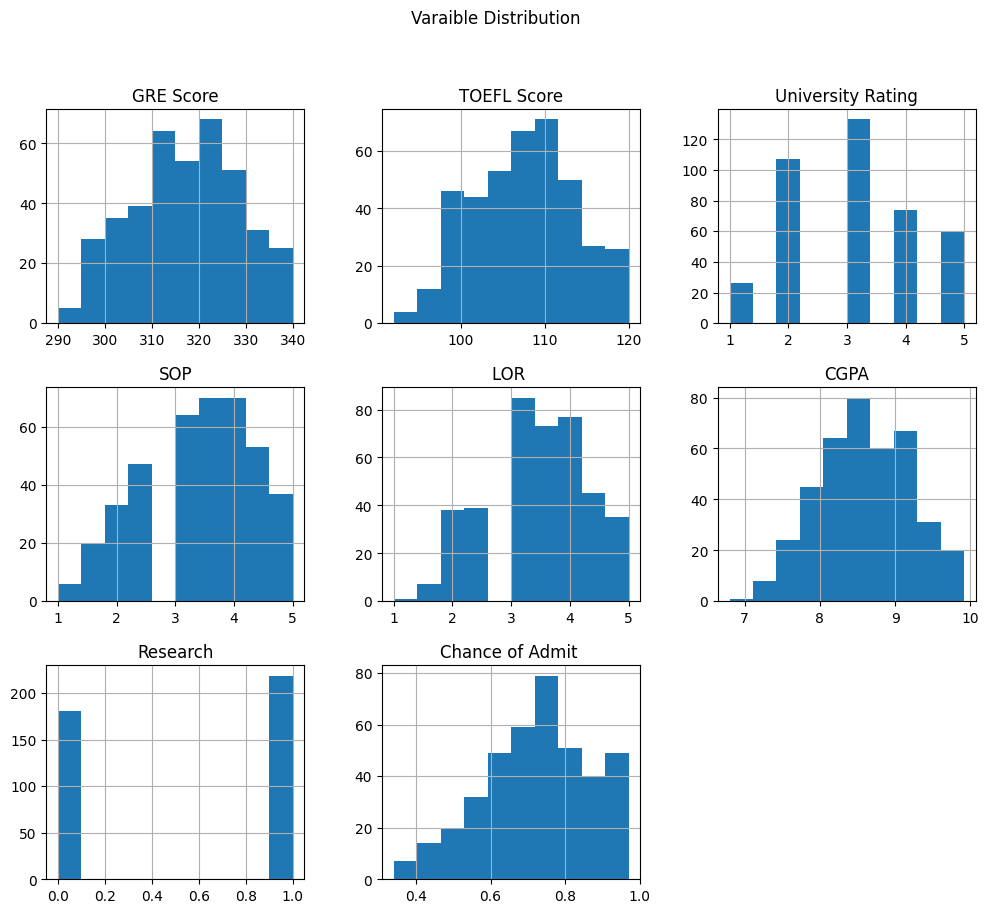

In [8]:
df.hist(figsize=(12,10), bins=10)
plt.suptitle('Varaible Distribution')
plt.show()

In [9]:
df.columns

Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA',
       'Research', 'Chance of Admit '],
      dtype='object')

In [10]:
X = df[['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA',
       'Research']]
y = df['Chance of Admit ']

In [12]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [79]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('lr', LinearRegression(n_jobs=-1))
])

In [80]:
from sklearn.model_selection import cross_val_score, KFold
cv = KFold(n_splits=5, shuffle=True, random_state=42)
model = pipeline.fit(X_train, y_train)

In [81]:
model

,steps,"[('lr', ...)]"
,transform_input,None
,memory,None
,verbose,False
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,-1
,positive,False


In [82]:
score = cross_val_score(model,X_train, y_train, cv=cv, scoring='r2')
print(score)
print(np.mean(score))

[0.69826375 0.76629614 0.78266678 0.79957645 0.81423375]
0.7722073759237562


In [83]:
y_pred = model.predict(X_test)

In [84]:
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
mse

0.004617003377285013

In [85]:
lr_score = model.score(X_test, y_test)
print(f'Model Trained. Accuracy on Test Set (R2 Score): {lr_score:.4f}')

Model Trained. Accuracy on Test Set (R2 Score): 0.8212


In [88]:
import pickle 
with open('admissions_model.pkl', 'wb') as f:
    pickle.dump(model, f)
print(f"Model saved as 'admission_model.pkl'")

Model saved as 'admission_model.pkl'


In [89]:
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f"Scaled Values saved as 'scaler.pkl'")

Scaled Values saved as 'scaler.pkl'


In [90]:
with open('X.txt', 'w') as f:
    for feature in X:
        f.write(f'{feature}\n')

In [91]:
scaler.mean_

array([316.8075  , 107.41    ,   3.0875  ,   3.4     ,   3.4525  ,
         8.598925,   0.5475  ])

In [92]:
scaler.scale_

array([11.45929508,  6.06192214,  1.14229758,  1.00560927,  0.89735375,
        0.59557123,  0.49773864])

In [ ]:
r2_score